# Week 1 Seminar

A/B experiment analysis

In [1]:
from collections import namedtuple

import pandas as pd
import numpy as np
import scipy.stats as ss

import matplotlib.pyplot as plt

pd.set_option("display.precision", 3)

%matplotlib inline

In [2]:
experiment = "TOP_POP"

In [3]:
data = pd.read_json("/Users/anndosova/RecSys/logs/experiments/seminar2_v2/data.json", lines=True)
data["treatment"] = data["experiments"].map(lambda experiments: experiments[experiment])

In [4]:
data.head()

,message,timestamp,user,track,time,latency,recommendation,experiments,treatment
0,next,2025-02-17 19:15:12.046,8669,11,1.00,6.418e-04,507.0,{'TOP_POP': 'T2'},T2
1,next,2025-02-17 19:15:12.048,169,15992,1.00,3.612e-04,3224.0,{'TOP_POP': 'T2'},T2
2,next,2025-02-17 19:15:12.051,8669,507,0.91,4.227e-04,528.0,{'TOP_POP': 'T2'},T2
3,next,2025-02-17 19:15:12.053,169,3224,0.06,4.337e-04,496.0,{'TOP_POP': 'T2'},T2
4,next,2025-02-17 19:15:12.055,8669,528,1.00,3.381e-04,549.0,{'TOP_POP': 'T2'},T2


## Visualize sessions

In [5]:
Session = namedtuple("Session", ["timestamp", "tracks", "time", "latency"])

def sessionize(user_data):
    sessions = []
    session = None
    for _, row in user_data.sort_values("timestamp").iterrows():
        if session is None:
            session = Session(row["timestamp"], 0, 0, 0)
        
        session = session._replace(
            tracks = session.tracks + 1, 
            time = session.time + row["time"],
            latency = session.latency + row["latency"] * 1000,
        )
        
        if row["message"] == "last":
            sessions.append(session._asdict())
            session = None
    return sessions

In [6]:
sessions = (
    data
    .groupby(["user", "treatment"])
    .apply(sessionize)
    .explode()
    .apply(pd.Series)
)

In [7]:
sessions.head(2)

timestamp  tracks  time  latency
user treatment                                               
0    T1        2025-02-17 19:15:30.494       7  2.25    1.566
     T1        2025-02-17 19:16:09.651       6  1.10    1.664

In [8]:
data[data['user'] == 0]

,message,timestamp,user,track,time,latency,recommendation,experiments,treatment
6670,next,2025-02-17 19:15:30.494,0,8054,1.00,2.170e-04,15.0,{'TOP_POP': 'T1'},T1
6672,next,2025-02-17 19:15:30.498,0,15,0.26,2.236e-04,952.0,{'TOP_POP': 'T1'},T1
6674,next,2025-02-17 19:15:30.502,0,952,0.01,2.298e-04,15.0,{'TOP_POP': 'T1'},T1
6676,next,2025-02-17 19:15:30.505,0,15,0.00,2.193e-04,84.0,{'TOP_POP': 'T1'},T1
6678,next,2025-02-17 19:15:30.509,0,84,0.98,2.289e-04,84.0,{'TOP_POP': 'T1'},T1
6680,next,2025-02-17 19:15:30.513,0,84,0.00,2.208e-04,15.0,{'TOP_POP': 'T1'},T1
6682,last,2025-02-17 19:15:30.517,0,15,0.00,2.263e-04,NaN,{'TOP_POP': 'T1'},T1
19236,next,2025-02-17 19:16:09.651,0,552,1.00,3.045e-04,3221.0,{'TOP_POP': 'T1'},T1
19238,next,2025-02-17 19:16:09.662,0,3221,0.00,2.985e-04,4081.0,{'TOP_POP': 'T1'},T1
19240,next,2025-02-17 19:16:09.672,0,4081,0.00,2.699e-04,4450.0,{'TOP_POP': 'T1'},T1


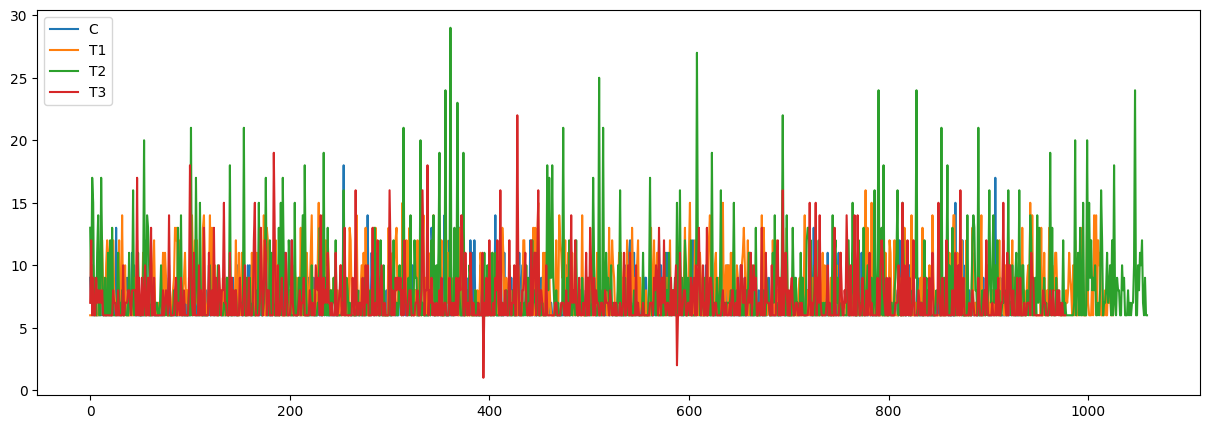

In [9]:
figure, ax = plt.subplots(figsize=(15, 5))
for treatment, treatment_sessions in sessions.groupby("treatment"):
    reindexed_treatment_sessions = treatment_sessions.sort_values("timestamp").reset_index()
    ax.plot(reindexed_treatment_sessions.index, reindexed_treatment_sessions["tracks"], label=treatment)
ax.legend()
pass

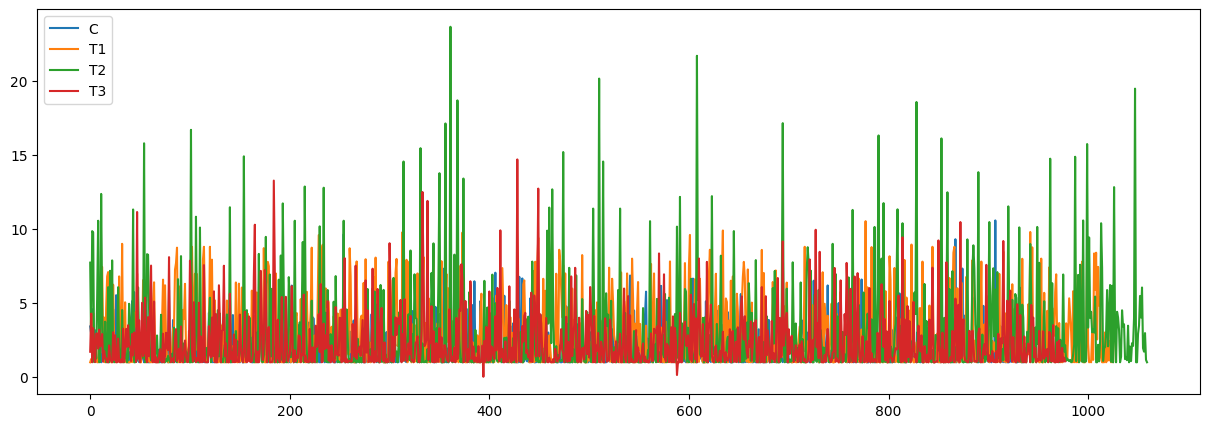

In [10]:
figure, ax = plt.subplots(figsize=(15, 5))
for treatment, treatment_sessions in sessions.groupby("treatment"):
    reindexed_treatment_sessions = treatment_sessions.sort_values("timestamp").reset_index()
    ax.plot(reindexed_treatment_sessions.index, reindexed_treatment_sessions["time"], label=treatment)
ax.legend()
pass

## Analyze the experiment

In [11]:
user_level_data = (
  sessions
    .reset_index()
    .groupby(["user", "treatment"])
    .agg(
        {
            "timestamp": "count",
            "tracks": "sum",
            "time": "sum",
            "latency": "sum"
        }
    )
)

user_level_data["sessions"] = user_level_data["timestamp"]
user_level_data["mean_request_latency"] = user_level_data["latency"] / user_level_data["tracks"]
user_level_data["mean_tracks_per_session"] = user_level_data["tracks"] / user_level_data["sessions"]
user_level_data["mean_time_per_session"] = user_level_data["time"] / user_level_data["sessions"]

metrics = [
    "time", 
    "sessions", 
    "mean_request_latency", 
    "mean_tracks_per_session", 
    "mean_time_per_session"
]

user_level_metrics = user_level_data[metrics].copy().reset_index()

In [12]:
treatment_level_metrics = (
    user_level_metrics
    .groupby("treatment")[metrics]
    .agg(["count", "mean", "var"])
)

In [13]:
def dof(n_0, n_1, s2_0, s2_1):
    numerator = (s2_0 / n_0 + s2_1 / n_1) * (s2_0 / n_0 + s2_1 / n_1)
    denominator = s2_0 * s2_0 / n_0 / n_0 / (n_0 - 1) + s2_1 * s2_1 / n_1 / n_1 / (n_1 - 1)
    return numerator / denominator


def ci(n_0, n_1, s2_0, s2_1, alpha=0.05):
    return ss.t.ppf(1 - alpha/2, dof(n_0, n_1, s2_0, s2_1)) * np.sqrt(s2_0 / n_0 + s2_1 / n_1)


effects = []

control = [data for treatment, data in treatment_level_metrics.iterrows() if treatment == "C"][0]

for treatment, row in treatment_level_metrics.iterrows():
    if treatment == "C":
        continue
    
    for metric in metrics:
        control_mean = control[metric]["mean"]
        treatment_mean = row[metric]["mean"]
        
        effect = treatment_mean - control_mean
        conf_int = ci(
            control[metric]["count"],
            row[metric]["count"],
            control[metric]["var"],
            row[metric]["var"],
        )
        effects.append({
            "treatment": treatment,
            "metric": metric,
            "control_mean": control_mean,
            "treatment_mean": treatment_mean,
            "effect": effect / control_mean * 100,
            "lower": (effect - conf_int) / control_mean * 100,
            "upper": (effect + conf_int) / control_mean * 100,
            "significant": (effect + conf_int) * (effect - conf_int) > 0
        })

In [14]:
def color(value):
    return 'color:red;' if value < 0 else 'color:green;'

def background(value):
    return 'color:white;background-color:green' if value else 'color:white;background-color:red'
        

(
    pd.DataFrame(effects)[[
        "treatment", 
        "metric",
        "effect", 
        "upper", 
        "lower", 
        "control_mean", 
        "treatment_mean",
        "significant"
    ]]
    .sort_values(["metric", "treatment"], ascending=False)
    .style
    .applymap(color, subset=["effect", "upper", "lower"])
    .applymap(background, subset=["significant"])
)

,treatment,metric,effect,upper,lower,control_mean,treatment_mean,significant
10,T3,time,23.663,33.563,13.763,2.285,2.826,True
5,T2,time,57.356,70.120,44.592,2.285,3.596,True
0,T1,time,54.432,65.580,43.284,2.285,3.529,True
11,T3,sessions,-0.818,3.037,-4.674,1.216,1.206,False
6,T2,sessions,0.208,3.949,-3.534,1.216,1.218,False
1,T1,sessions,2.757,6.672,-1.158,1.216,1.249,False
13,T3,mean_tracks_per_session,6.957,9.598,4.317,6.856,7.333,True
8,T2,mean_tracks_per_session,16.466,20.025,12.906,6.856,7.984,True
3,T1,mean_tracks_per_session,13.566,16.302,10.830,6.856,7.786,True
14,T3,mean_time_per_session,24.839,33.426,16.251,1.865,2.329,True
